In [253]:
# Importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [254]:
retail = pd.read_csv(r"U:\online+shoppers+purchasing+intention+dataset\online_shoppers_intention.csv")

In [255]:
retail.shape

(12330, 18)

In [256]:
retail.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [257]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [258]:
retail.isnull().sum()[retail.isnull().sum()>0]

Series([], dtype: int64)

# EDA

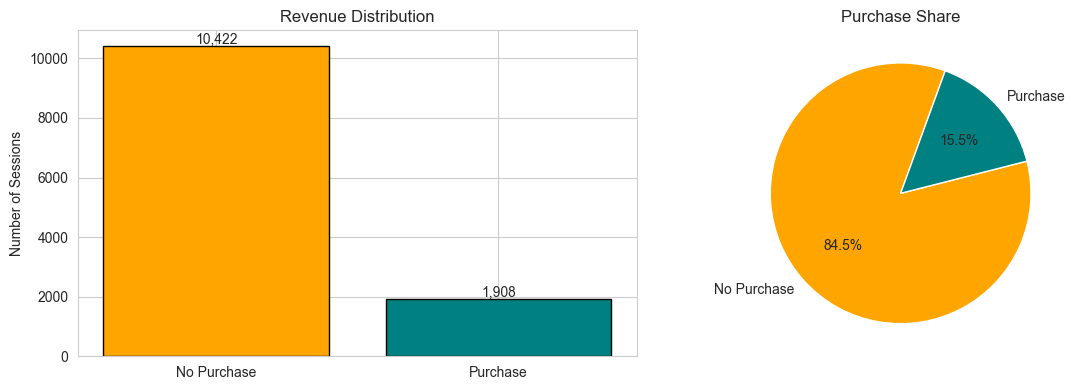

In [259]:
# Checking class distribution in target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = retail['Revenue'].value_counts()

# Bar chart
axes[0].bar(['No Purchase', 'Purchase'],counts.values,color=['orange', 'Teal'],edgecolor = 'black')
axes[0].set_title('Revenue Distribution')
axes[0].set_ylabel('Number of Sessions')
for i, value in enumerate(counts.values):
    axes[0].text(i, value + 80, f'{value:,}', ha = 'center')

# Pie chart
axes[1].pie(counts.values,labels = ['No Purchase', 'Purchase'],autopct = '%1.1f%%',startangle = 70 , colors = ['orange', 'Teal'])
axes[1].set_title('Purchase Share')
plt.tight_layout()
plt.show()

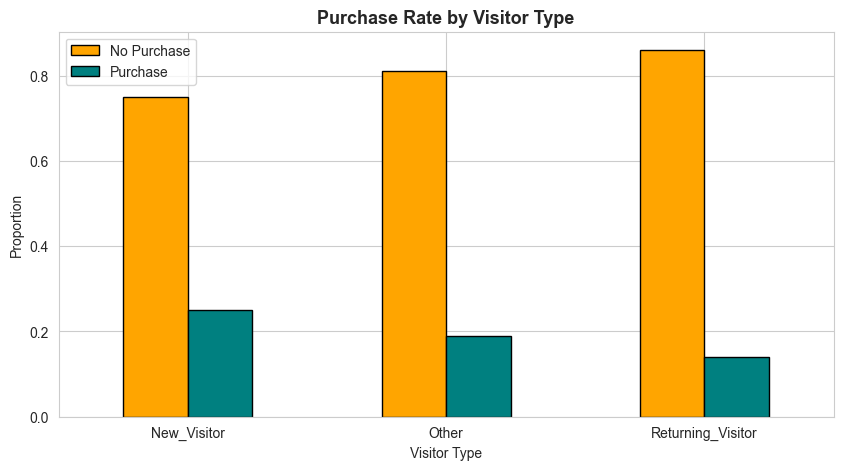

In [260]:
#     VISITOR TYPE vs PURCHASE 

visitor_revenue = retail.groupby('VisitorType')['Revenue'].value_counts(normalize = True).unstack()
visitor_revenue.plot(kind ='bar',color = ['orange', 'Teal'],edgecolor = 'black',rot = 0)
plt.title('Purchase Rate by Visitor Type', fontsize = 13, fontweight = 'bold')
plt.xlabel('Visitor Type')
plt.ylabel('Proportion')
plt.legend(['No Purchase', 'Purchase'])
plt.show()

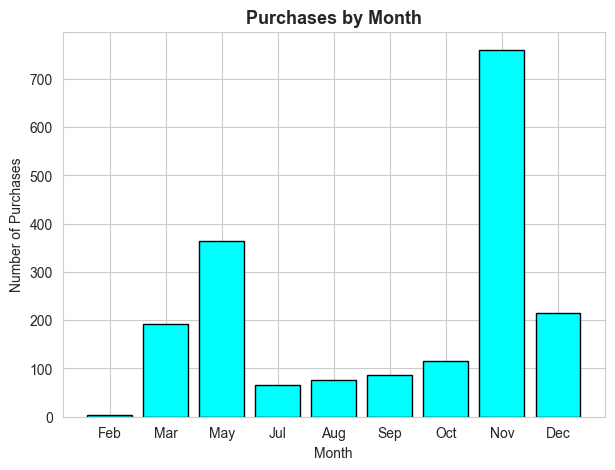

In [261]:
#     MONTH vs PURCHASE 

plt.figure(figsize=(7,5))
month_order = ['Feb', 'Mar', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_revenue = retail[retail['Revenue'] == True]['Month'].value_counts()
available_months = [m for m in month_order if m in month_revenue.index]
month_revenue = month_revenue.reindex(available_months).fillna(0)
plt.bar(month_revenue.index,month_revenue.values,color = 'cyan',edgecolor = 'black')
plt.title('Purchases by Month', fontsize = 13, fontweight = 'bold')
plt.xlabel('Month')
plt.ylabel('Number of Purchases')
plt.show()

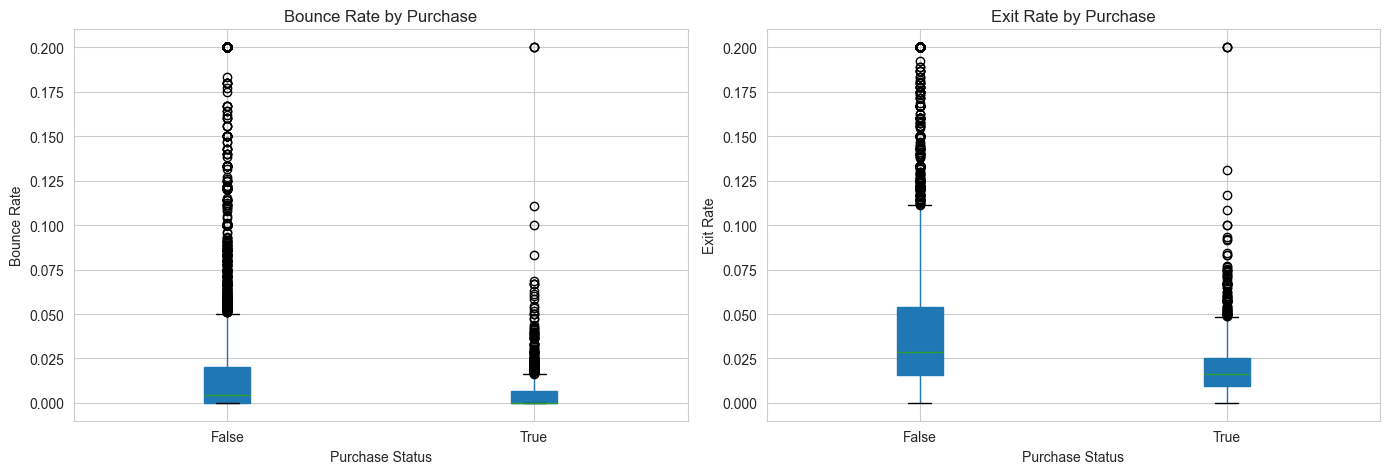

Observation: Customers who made a purchase generally had lower bounce and exit rates.


In [262]:
# Bounce Rate & Exit Rate vs Purchase

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bounce Rate
retail.boxplot(column = 'BounceRates', by = 'Revenue', ax = axes[0],patch_artist=True)
axes[0].set_title('Bounce Rate by Purchase')
axes[0].set_xlabel('Purchase Status')
axes[0].set_ylabel('Bounce Rate')

# Exit Rate
retail.boxplot(column = 'ExitRates',by = 'Revenue', ax=axes[1], patch_artist = True)
axes[1].set_title('Exit Rate by Purchase')
axes[1].set_xlabel('Purchase Status')
axes[1].set_ylabel('Exit Rate')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("Observation: Customers who made a purchase generally had lower bounce and exit rates.")

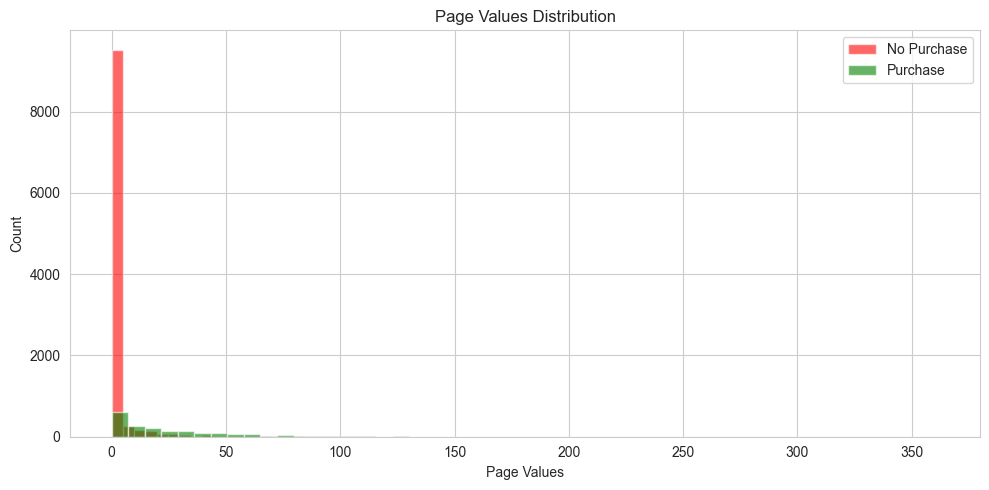

Observation: Sessions with higher page values were more likely to result in a purchase.


In [263]:
# Page Values vs Purchase

fig, ax = plt.subplots(figsize=(10, 5))

retail[retail['Revenue'] == False]['PageValues'].plot(kind = 'hist', bins = 50, alpha = 0.6, label = 'No Purchase', color ='red', ax = ax)
retail[retail['Revenue'] == True]['PageValues'].plot(kind = 'hist',bins = 50, alpha = 0.6,label = 'Purchase',color = 'green',ax = ax)
ax.set_title('Page Values Distribution')
ax.set_xlabel('Page Values')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: Sessions with higher page values were more likely to result in a purchase.")

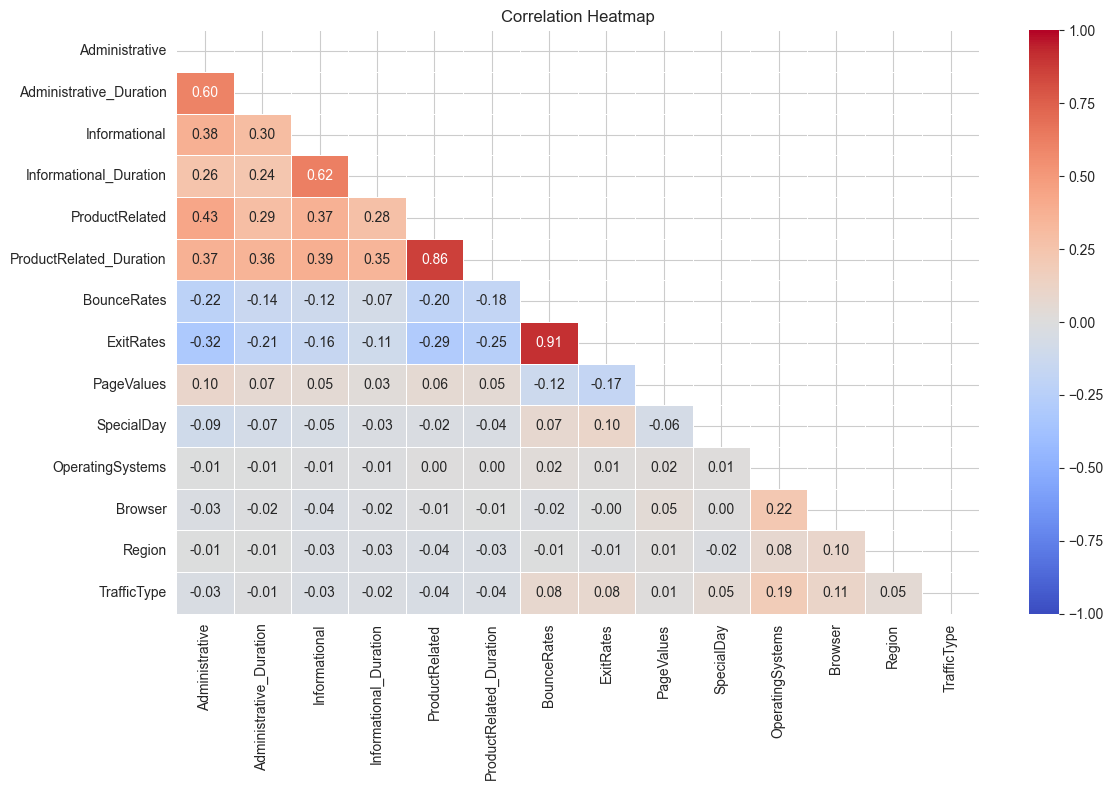

Observation: BounceRates and ExitRates show a strong positive correlation.


In [264]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))
numeric_cols = retail.select_dtypes(include = [np.number]).columns.tolist()
corr_matrix = retail[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap( corr_matrix, annot = True, fmt = '.2f',cmap = 'coolwarm', mask = mask, linewidths = 0.5, vmin = -1,vmax = 1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Observation: BounceRates and ExitRates show a strong positive correlation.")

# DATA PREPROCESSING

In [265]:
retail.select_dtypes(include=['object', 'bool']).columns

Index(['Month', 'VisitorType', 'Weekend', 'Revenue'], dtype='object')

In [266]:
from sklearn.preprocessing import LabelEncoder

# Find categorical columns
cat_cols = retail.select_dtypes(include=['object', 'bool']).columns

# Encode each column separately
for col in cat_cols:
    le = LabelEncoder()
    retail[col] = le.fit_transform(retail[col])

In [267]:
print(retail.dtypes) #All columns converted to int and float

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object


In [268]:
# Dividing the data into train and test

from sklearn.model_selection import train_test_split
retail_train, retail_test = train_test_split(retail, test_size=0.2,random_state=42, stratify=retail['Revenue'])

retail_train_x = retail_train.iloc[:, :-1]
retail_train_y = retail_train.iloc[:, -1]

retail_test_x = retail_test.iloc[ : ,  :-1]
retail_test_y = retail_test.iloc[ : , -1]

# Handling Class Imbalance using SMOTE

In [269]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()

x_train_smote, y_train_smote = smote.fit_resample(retail_train_x, retail_train_y)

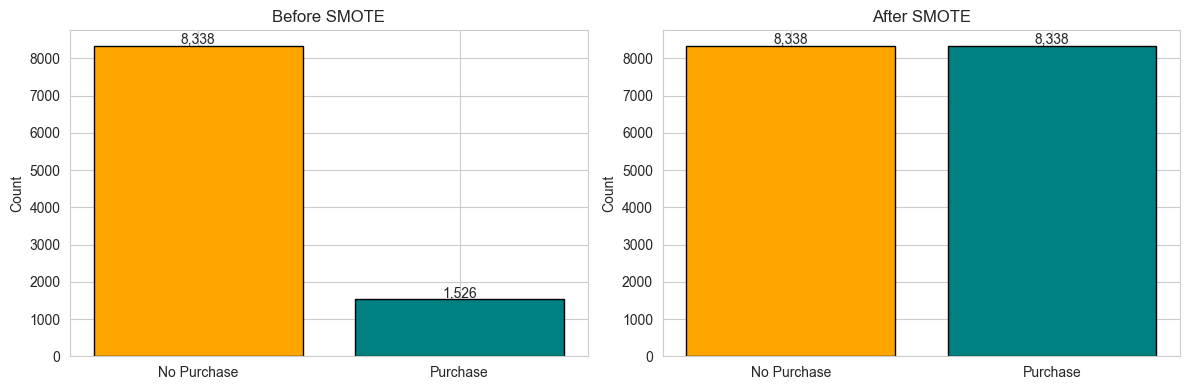

In [270]:
# Class distribution before and after SMOTE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
before = retail_train_y.value_counts()
axes[0].bar(['No Purchase', 'Purchase'],before.values,color = ['orange', 'teal'], edgecolor = 'black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, value in enumerate(before.values):
    axes[0].text(i, value + 50, f'{value:,}', ha='center')

# After SMOTE
after = pd.Series(y_train_smote).value_counts()
axes[1].bar(['No Purchase', 'Purchase'],after.values,color = ['orange', 'teal'], edgecolor = 'black')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, value in enumerate(after.values):
    axes[1].text(i, value + 50, f'{value:,}', ha ='center')

plt.tight_layout()
plt.show()

# Model Building

In [271]:
# Feature scaling for Logistic regression 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train_smote)
X_test_scaled  = scaler.transform(retail_test_x)

In [272]:
from sklearn.metrics import confusion_matrix , classification_report

In [288]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train_scaled , y_train_smote)
pred_lr = logreg.predict(X_test_scaled)
tab = confusion_matrix(retail_test_y , pred_lr)
print(tab)
print('-------------------------------------------------------------')
print(classification_report(retail_test_y , pred_lr, target_names = ['No Purchase', 'Purchase']))

[[1864  220]
 [ 114  268]]
-------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.94      0.89      0.92      2084
    Purchase       0.55      0.70      0.62       382

    accuracy                           0.86      2466
   macro avg       0.75      0.80      0.77      2466
weighted avg       0.88      0.86      0.87      2466



In [289]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train_smote , y_train_smote)
pred_dt = dt.predict(retail_test_x)
tab = confusion_matrix(retail_test_y , pred_dt)
print(tab)
print('-------------------------------------------------------------')
print(classification_report(retail_test_y , pred_dt, target_names = ['No Purchase', 'Purchase']))

[[1851  233]
 [ 143  239]]
-------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.93      0.89      0.91      2084
    Purchase       0.51      0.63      0.56       382

    accuracy                           0.85      2466
   macro avg       0.72      0.76      0.73      2466
weighted avg       0.86      0.85      0.85      2466



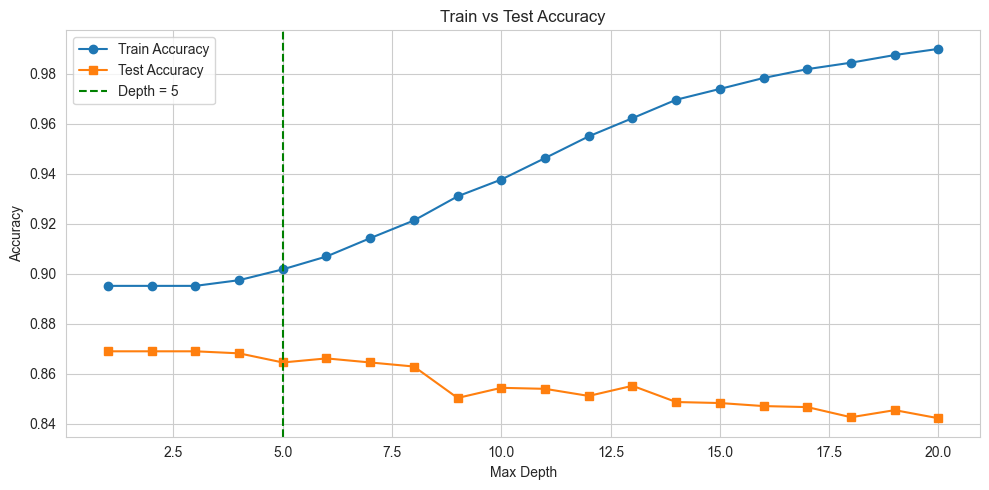

Observation: Higher depth improves training accuracy,
but test accuracy starts dropping after a point.


In [278]:
# Checking overfitting in Decision Tree

depths = range(1, 21)

train_scores = []
test_scores = []

for d in depths:
    dt_temp = DecisionTreeClassifier(max_depth = d, random_state=42)
    dt_temp.fit(x_train_smote, y_train_smote)
    train_scores.append(dt_temp.score(x_train_smote, y_train_smote))
    test_scores.append(dt_temp.score(retail_test_x, retail_test_y))
    
# Plotting accuracy
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores,marker='o',label='Train Accuracy')
plt.plot(depths,test_scores,marker='s',label='Test Accuracy')
plt.axvline(x = 5,linestyle='--', color = 'green',label = 'Depth = 5')
plt.title('Train vs Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print("Observation: Higher depth improves training accuracy,")
print("but test accuracy starts dropping after a point.")

In [275]:
from sklearn.model_selection import GridSearchCV

search_dict = { 'criterion' : ('gini' , 'entropy' ),
                'max_depth' : ( 5,6,7,8,9,10),
                'min_samples_split' : ( 25 , 30, 35, 40, 45, 50, 75 , 90, 100)}

In [276]:
grid = GridSearchCV( dt , param_grid = search_dict,cv = 5,scoring = 'f1', verbose = 1)
grid.fit(x_train_smote , y_train_smote)
print("Best Parameters:", grid.best_params_)
print(f"Best CV F1 Score: {grid.best_score_:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 40}
Best CV F1 Score: 0.90


In [290]:
pred_dt = grid.predict(retail_test_x)
tab = confusion_matrix(retail_test_y, pred_dt)
print(tab)

print("-----------------------------------------------------")
print(classification_report(retail_test_y, pred_dt))

[[1853  231]
 [ 110  272]]
-----------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      2084
           1       0.54      0.71      0.61       382

    accuracy                           0.86      2466
   macro avg       0.74      0.80      0.77      2466
weighted avg       0.88      0.86      0.87      2466



In [292]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(x_train_smote , y_train_smote)
pred_rf  = rfc.predict(retail_test_x)
tab = confusion_matrix(retail_test_y , pred_rf)
print(tab)
print('-------------------------------------------------------------')
print(classification_report(retail_test_y, pred_rf, target_names=['No Purchase', 'Purchase']))

[[1903  181]
 [ 106  276]]
-------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.95      0.91      0.93      2084
    Purchase       0.60      0.72      0.66       382

    accuracy                           0.88      2466
   macro avg       0.78      0.82      0.79      2466
weighted avg       0.89      0.88      0.89      2466



In [293]:
rfc.feature_importances_

array([0.0300323 , 0.06131623, 0.01114596, 0.01903463, 0.04575724,
       0.06755922, 0.04530203, 0.08721048, 0.48825826, 0.00665512,
       0.03031904, 0.01983733, 0.01319561, 0.01958059, 0.01856705,
       0.02649333, 0.00973559])

In [294]:
x_train_smote.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend'],
      dtype='object')

In [295]:
feat_imp = pd.DataFrame({'Features' : x_train_smote.columns , 
                         'IMP' : rfc.feature_importances_})
feat_imp = feat_imp.sort_values('IMP' , ascending = False)
feat_imp

,Features,IMP
8,PageValues,0.488258
7,ExitRates,0.087210
5,ProductRelated_Duration,0.067559
1,Administrative_Duration,0.061316
4,ProductRelated,0.045757
6,BounceRates,0.045302
10,Month,0.030319
0,Administrative,0.030032
15,VisitorType,0.026493
11,OperatingSystems,0.019837


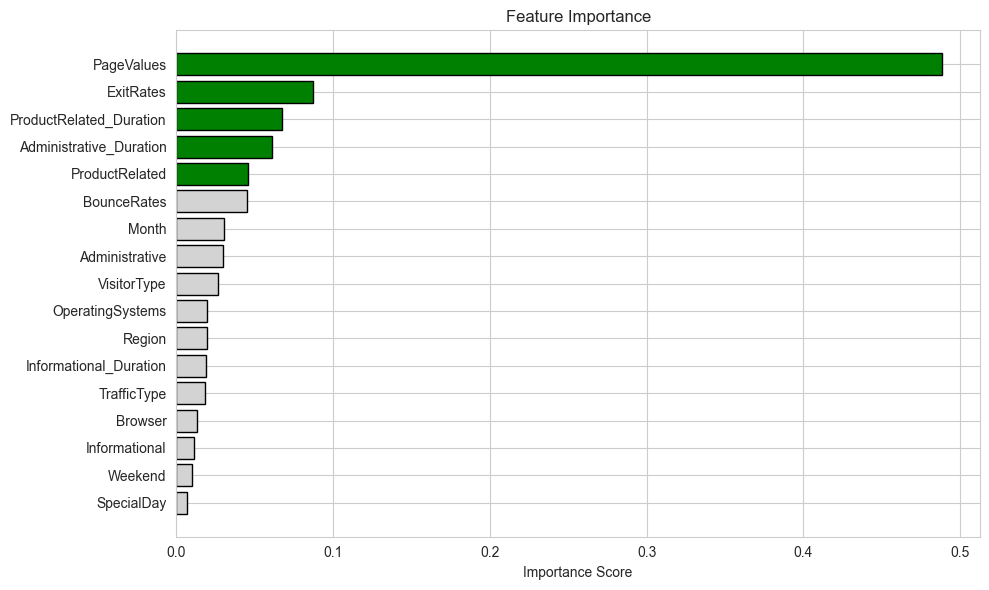

Top 5 Features:

               Features      IMP
             PageValues 0.488258
              ExitRates 0.087210
ProductRelated_Duration 0.067559
Administrative_Duration 0.061316
         ProductRelated 0.045757

Observation: PageValues appears to have the highest impact on purchase prediction.


In [296]:
#  Visualize Feature Importance
plt.figure(figsize=(10, 6))

colors = ['green' if i < 5 else 'lightgray' for i in range(len(feat_imp))]
plt.barh(feat_imp['Features'][::-1], feat_imp['IMP'][::-1], color = colors[::-1], edgecolor = 'black')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 Features:\n")
print(feat_imp[['Features', 'IMP']].head().to_string(index=False))
print("\nObservation: PageValues appears to have the highest impact on purchase prediction.")

In [298]:
# Retrain using Top 10 Features only
top10 = feat_imp['Features'].head(10).tolist()

X_top_train = x_train_smote[top10]
X_top_test  = retail_test_x[top10]       #  filter test set to same 10 features

rfc_top = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_top.fit(X_top_train, y_train_smote)

pred_top = rfc_top.predict(X_top_test)   #  predict on X_top_test, not retail_test_x

tab = confusion_matrix(retail_test_y, pred_top)
print(tab)
print('-------------------------------------------------------------')
print(classification_report(retail_test_y, pred_top, target_names=['No Purchase', 'Purchase']))

[[1891  193]
 [ 109  273]]
-------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.95      0.91      0.93      2084
    Purchase       0.59      0.71      0.64       382

    accuracy                           0.88      2466
   macro avg       0.77      0.81      0.78      2466
weighted avg       0.89      0.88      0.88      2466



In [286]:
print("""
Observation: Feature selection with top 10 features gives almost identical 
performance to using all 17 features (F1: 0.65 vs 0.66, Accuracy: 88% both).

This confirms 7 features were contributing minimal signal.
Simpler model is preferred — faster inference, less overfitting risk,
and easier to explain to business stakeholders.
""")


Observation: Feature selection with top 10 features gives almost identical 
performance to using all 17 features (F1: 0.65 vs 0.66, Accuracy: 88% both).

This confirms 7 features were contributing minimal signal.
Simpler model is preferred — faster inference, less overfitting risk,
and easier to explain to business stakeholders.



In [302]:
# Predicted probabilities for all 3 models
prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]
prob_dt = grid.predict_proba(retail_test_x)[:, 1]
prob_rf = rfc.predict_proba(retail_test_x)[:, 1]

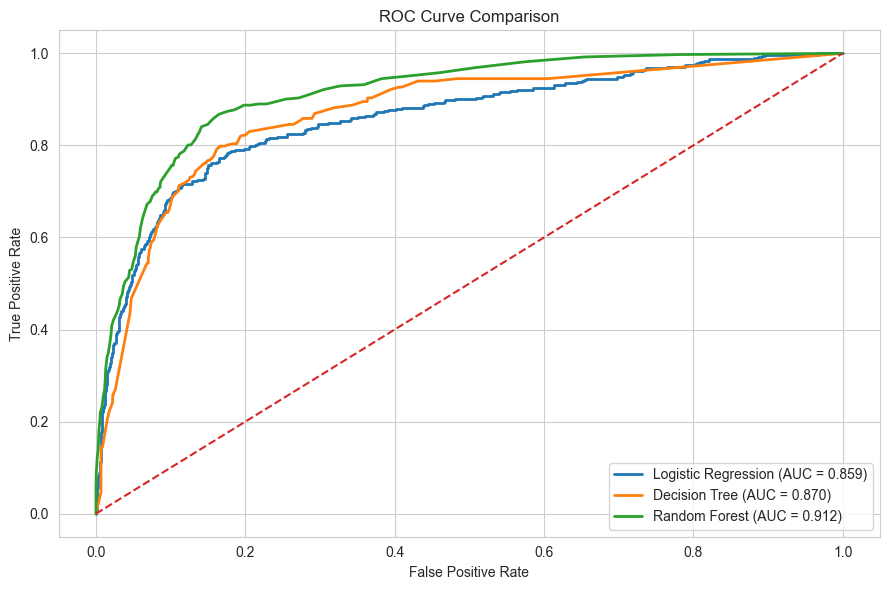

In [303]:
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay

# ROC CURVES
plt.figure(figsize=(9, 6))

models = [('Logistic Regression', prob_lr),
          ('Decision Tree', prob_dt),
          ('Random Forest', prob_rf)]

for name, prob in models:
    fpr, tpr, _ = roc_curve(retail_test_y, prob)
    auc = roc_auc_score(retail_test_y, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

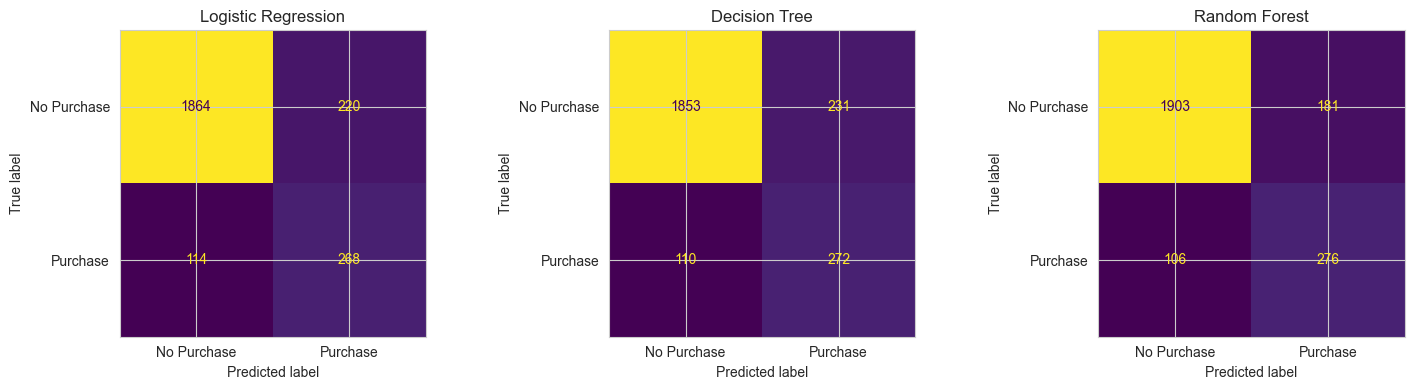

In [304]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
predictions = [('Logistic Regression', pred_lr),
               ('Decision Tree', pred_dt),
               ('Random Forest', pred_rf)]

for ax, (name, pred) in zip(axes, predictions):
    cm = confusion_matrix(retail_test_y, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase']).plot(ax = ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [307]:
# Model comparison table
results = pd.DataFrame({'Model': ['Logistic Regression','Decision Tree','Random Forest'],
                        'Accuracy': [accuracy_score(retail_test_y, p) for p in [pred_lr, pred_dt, pred_rf]],
                        'Precision': [precision_score(retail_test_y, p) for p in [pred_lr, pred_dt, pred_rf]],
                        'Recall': [recall_score(retail_test_y, p) for p in [pred_lr, pred_dt, pred_rf]],
                        'F1 Score': [f1_score(retail_test_y, p) for p in [pred_lr, pred_dt, pred_rf]],
                        'AUC-ROC': [roc_auc_score(retail_test_y, p) for p in [prob_lr, prob_dt, prob_rf]]}).round(2)

print("\nModel Performance Comparison\n")
print(results.to_string(index=False))

best = results.loc[results['AUC-ROC'].idxmax(),'Model']
best_auc = results['AUC-ROC'].max()

print(f"\nBest Model : {best}")
print(f"AUC-ROC    : {best_auc:.2f}")


Model Performance Comparison

              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression      0.86       0.55    0.70      0.62     0.86
      Decision Tree      0.86       0.54    0.71      0.61     0.87
      Random Forest      0.88       0.60    0.72      0.66     0.91

Best Model : Random Forest
AUC-ROC    : 0.91
